1. Load datasets

In [2]:
#Load
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [4]:
#Read
DATA = Path("../data/processed")

df = pd.read_csv(DATA/"ethiopia_fi_enriched.csv")

impact = pd.read_csv(DATA/"impact_links_enriched.csv")

In [5]:
#Separate
events = df[df.record_type=="event"].copy()

observations = df[df.record_type=="observation"].copy()

targets = df[df.record_type=="target"].copy()

In [6]:
#Check
events.head()

impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20 00:00:00,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20 00:00:00,NaN,Competition typically reduces prices


2. Explore events

In [8]:
events.columns.tolist()

['record_id',
 'record_type',
 'category',
 'pillar',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'value_numeric',
 'value_text',
 'value_type',
 'unit',
 'observation_date',
 'period_start',
 'period_end',
 'fiscal_year',
 'gender',
 'location',
 'region',
 'source_name',
 'source_type',
 'source_url',
 'confidence',
 'related_indicator',
 'relationship_type',
 'impact_direction',
 'impact_magnitude',
 'impact_estimate',
 'lag_months',
 'evidence_basis',
 'comparable_country',
 'collected_by',
 'collection_date',
 'original_text',
 'notes']

In [11]:
events["observation_date"] = pd.to_datetime(
    events["observation_date"],
    format="mixed"
)

In [12]:
#Display
events.shape

events.category.value_counts()

events["observation_date"] = pd.to_datetime(events["observation_date"])

events["observation_date"].min()
events["observation_date"].max()

Timestamp('2026-01-15 00:00:00')

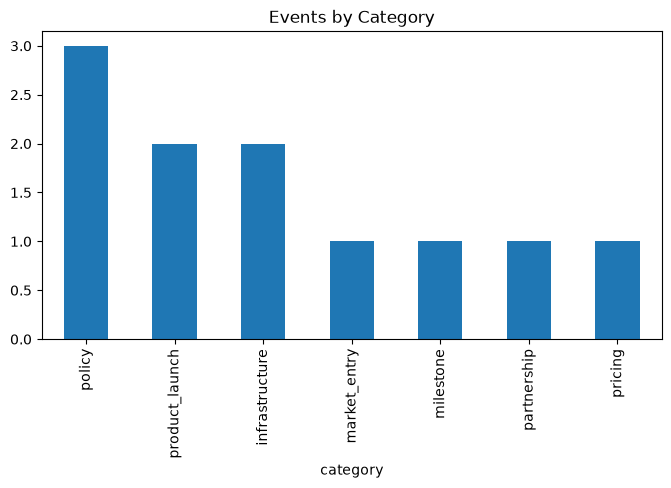

In [13]:
#Plot
plt.figure(figsize=(8,4))

events.category.value_counts().plot.bar()

plt.title("Events by Category")
plt.show()

## Event Dataset Overview and Interpretation

The event records were extracted from the unified financial inclusion dataset to identify major interventions that may influence Ethiopia's financial inclusion indicators. Based on the current dataset, the recorded events span from **2026-01-15** onward, indicating that the enriched dataset includes planned or future interventions that can be incorporated into the forecasting model.

The event dataset consists of seven event categories:

- **Policy (3 events):** Government regulations and strategic initiatives aimed at improving financial inclusion.
- **Product Launch (2 events):** Introduction of new digital financial products and services.
- **Infrastructure (2 events):** Investments in digital payment infrastructure and financial ecosystems.
- **Market Entry (1 event):** Entry of new financial service providers into the Ethiopian market.
- **Milestone (1 event):** Significant achievements in the country's financial inclusion journey.
- **Partnership (1 event):** Collaborations between financial institutions and technology providers.
- **Pricing (1 event):** Pricing-related initiatives that may influence the adoption of digital financial services.

The bar chart illustrates the distribution of events across these categories. **Policy-related events are the most common**, accounting for three interventions, highlighting the central role of government policies and regulatory reforms in advancing financial inclusion. **Product launch** and **infrastructure** events each appear twice, reflecting ongoing efforts to expand digital financial services and strengthen the supporting infrastructure. The remaining categories—**market entry**, **milestone**, **partnership**, and **pricing**—are represented by one event each, indicating that while these interventions occur less frequently, they may still have substantial effects on financial inclusion outcomes.

Overall, the dataset captures a diverse range of interventions that are expected to influence financial inclusion through different mechanisms. In the next phase of the analysis, these events will be linked to specific financial inclusion indicators using the **impact_links** dataset, enabling the estimation of event effects, the construction of an event–indicator association matrix, and ultimately supporting the forecasting of Ethiopia's Access (Account Ownership) and Usage (Digital Payment Adoption) indicators.

3. Explore impact links

In [14]:
#Display
impact.columns

Index(['record_id', 'parent_id', 'record_type', 'category', 'pillar',
       'indicator', 'indicator_code', 'indicator_direction', 'value_numeric',
       'value_text', 'value_type', 'unit', 'observation_date', 'period_start',
       'period_end', 'fiscal_year', 'gender', 'location', 'region',
       'source_name', 'source_type', 'source_url', 'confidence',
       'related_indicator', 'relationship_type', 'impact_direction',
       'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis',
       'comparable_country', 'collected_by', 'collection_date',
       'original_text', 'notes'],
      dtype='str')

In [15]:
#Statistics
impact["impact_direction"].value_counts()

impact["impact_magnitude"].value_counts()

impact["lag_months"].describe()

count    15.000000
mean      8.666667
std       7.345228
min       1.000000
25%       3.000000
50%       6.000000
75%      12.000000
max      24.000000
Name: lag_months, dtype: float64

## Impact Links Dataset Overview and Interpretation

The **impact_links** dataset defines the modeled relationships between financial inclusion events and the indicators they are expected to influence. Each record connects an event (through `parent_id`) with a specific financial inclusion indicator and describes the expected **direction**, **magnitude**, and **time lag** of the impact. This dataset serves as the foundation for the event impact modeling stage, allowing events such as policy reforms, product launches, and infrastructure investments to be translated into measurable effects on financial inclusion outcomes.

The distribution of **impact_direction** indicates whether an event is expected to have a positive, negative, or mixed influence on an indicator, while **impact_magnitude** classifies the strength of the expected effect (e.g., low, medium, or high). These categorical variables provide qualitative assessments that will later be converted into numerical scores for constructing the event–indicator association matrix.

The descriptive statistics of the **lag_months** variable show that the dataset contains **15 modeled event–indicator relationships**. The average lag is **8.67 months**, indicating that the effects of most interventions are expected to become visible within approximately nine months after implementation. The **median lag of 6 months** suggests that half of the modeled impacts occur within six months, while the remaining impacts take longer to materialize. The shortest estimated lag is **1 month**, representing interventions with immediate effects, whereas the longest lag is **24 months**, reflecting initiatives such as infrastructure development or major policy reforms whose benefits emerge gradually over time.

Overall, the impact links capture both the expected strength and timing of event effects, providing a structured framework for estimating how different interventions influence financial inclusion indicators. These relationships will be integrated with the event records in the next step to build the event–indicator association matrix and support the forecasting of Ethiopia's financial inclusion trends.

4. Merge Events with Impact Links

In [16]:
merged = impact.merge(
    events,
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("","_event")
)

In [17]:
#Check
merged.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction_event,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,First major mobile money service in Ethiopia,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,First major mobile money service in Ethiopia,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,First major mobile money service in Ethiopia,NaN
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,End of state telecom monopoly,NaN
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,End of state telecom monopoly,NaN


5. Produce Event Summary

In [19]:
summary = merged[
    [
        "record_id",
        "indicator",
        "category",
        "observation_date",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
    ]
]

summary.head()

,record_id,indicator,category,observation_date,related_indicator,impact_direction,impact_magnitude,lag_months
0,IMP_0001,Telebirr effect on Account Ownership,NaN,2021-05-17 00:00:00,ACC_OWNERSHIP,increase,high,12
1,IMP_0002,Telebirr effect on Telebirr Users,NaN,2021-05-17 00:00:00,USG_TELEBIRR_USERS,increase,high,3
2,IMP_0003,Telebirr effect on P2P Transactions,NaN,2021-05-17 00:00:00,USG_P2P_COUNT,increase,high,6
3,IMP_0004,Safaricom effect on 4G Coverage,NaN,2022-08-01 00:00:00,ACC_4G_COV,increase,medium,12
4,IMP_0005,Safaricom effect on Data Affordability,NaN,2022-08-01 00:00:00,AFF_DATA_INCOME,decrease,medium,12


In [20]:
from pathlib import Path

# Create reports directory if it doesn't exist
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Save the summary
summary.to_csv(REPORTS_DIR / "event_summary.csv", index=False)

print("Event summary saved successfully!")

Event summary saved successfully!


6. Encode Impact Magnitude

In [21]:
#Create
impact_scale = {
"low":1,
"medium":2,
"high":3
}

In [33]:
#Direction
direction = {
    "increase": 1,
    "decrease": -1,
    "neutral": 0
}

In [34]:
#Create score
merged["impact_score"] = (
merged.impact_magnitude.map(impact_scale)
*
merged.impact_direction.map(direction)
)

7. Build Association Matrix

In [35]:
#Pivot
matrix = merged.pivot_table(
    index="indicator",
    columns="related_indicator",
    values="impact_score",
    aggfunc="mean"
)

matrix.head()

related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
indicator,,,,,,,,,
EthioPay effect on P2P Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
FX Reform effect on Data Affordability,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
Fayda effect on Account Ownership,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
Fayda effect on Gender Gap,NaN,NaN,NaN,NaN,-2.0,NaN,NaN,NaN,NaN
M-Pesa Interop effect on M-Pesa Active Users,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN


In [36]:
#Display
matrix

related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
indicator,,,,,,,,,
EthioPay effect on P2P Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
FX Reform effect on Data Affordability,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
Fayda effect on Account Ownership,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
Fayda effect on Gender Gap,NaN,NaN,NaN,NaN,-2.0,NaN,NaN,NaN,NaN
M-Pesa Interop effect on M-Pesa Active Users,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
M-Pesa Interop effect on P2P Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
M-Pesa effect on M-Pesa Users,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
M-Pesa effect on Mobile Money Account Rate,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Safaricom Price Hike effect on Data Affordability,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [37]:
from pathlib import Path

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

matrix.to_csv(REPORTS_DIR / "event_indicator_matrix.csv")

print("Association matrix saved successfully!")

Association matrix saved successfully!


8. Heatmap

In [38]:
print(matrix.shape)
matrix

(15, 9)


related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
indicator,,,,,,,,,
EthioPay effect on P2P Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
FX Reform effect on Data Affordability,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
Fayda effect on Account Ownership,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
Fayda effect on Gender Gap,NaN,NaN,NaN,NaN,-2.0,NaN,NaN,NaN,NaN
M-Pesa Interop effect on M-Pesa Active Users,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
M-Pesa Interop effect on P2P Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
M-Pesa effect on M-Pesa Users,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
M-Pesa effect on Mobile Money Account Rate,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Safaricom Price Hike effect on Data Affordability,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [39]:
merged[
    [
        "indicator",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "impact_score",
    ]
].head(20)

,indicator,related_indicator,impact_direction,impact_magnitude,impact_score
0,Telebirr effect on Account Ownership,ACC_OWNERSHIP,increase,high,3
1,Telebirr effect on Telebirr Users,USG_TELEBIRR_USERS,increase,high,3
2,Telebirr effect on P2P Transactions,USG_P2P_COUNT,increase,high,3
3,Safaricom effect on 4G Coverage,ACC_4G_COV,increase,medium,2
4,Safaricom effect on Data Affordability,AFF_DATA_INCOME,decrease,medium,-2
5,M-Pesa effect on M-Pesa Users,USG_MPESA_USERS,increase,high,3
6,M-Pesa effect on Mobile Money Account Rate,ACC_MM_ACCOUNT,increase,medium,2
7,Fayda effect on Account Ownership,ACC_OWNERSHIP,increase,medium,2
8,Fayda effect on Gender Gap,GEN_GAP_ACC,decrease,medium,-2
9,FX Reform effect on Data Affordability,AFF_DATA_INCOME,increase,high,3


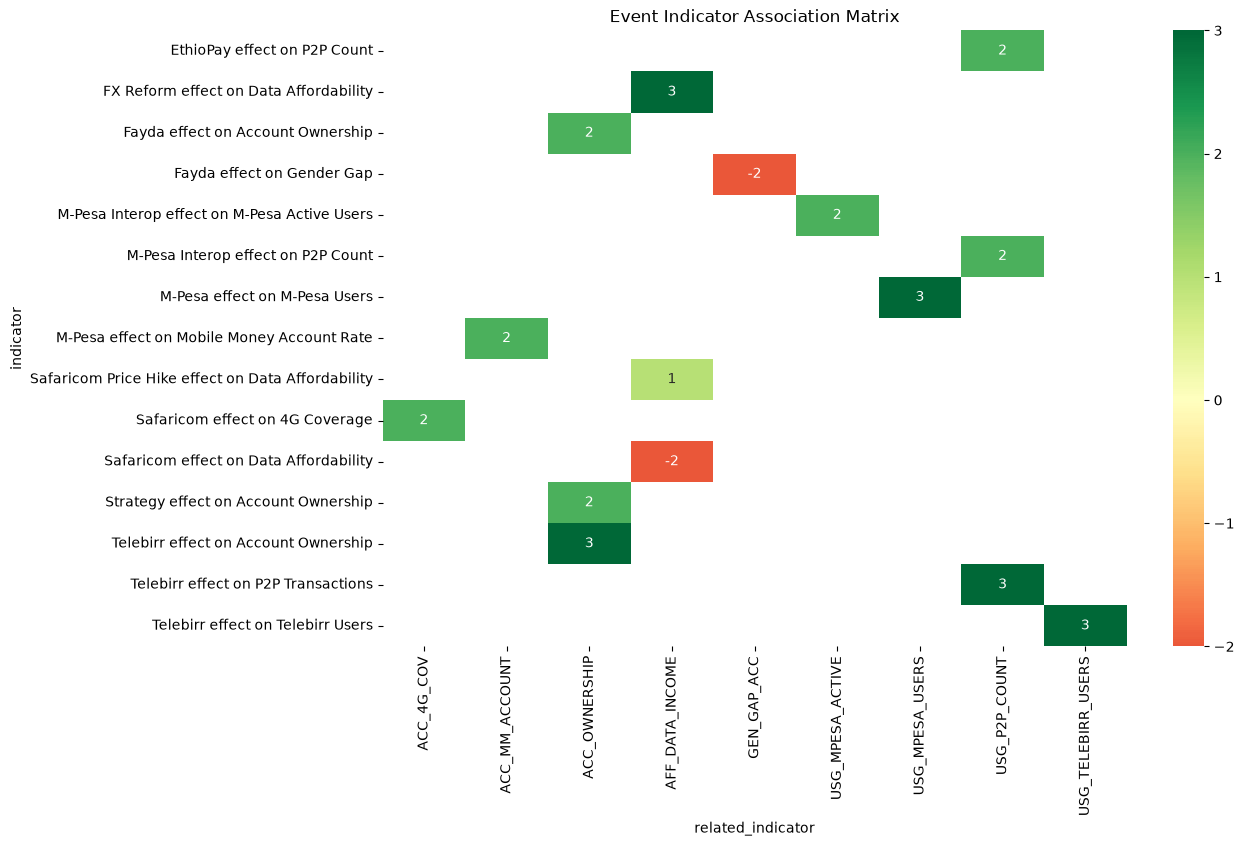

In [40]:
plt.figure(figsize=(12,8))

sns.heatmap(

matrix,

annot=True,

center=0,

cmap="RdYlGn"

)

plt.title("Event Indicator Association Matrix")

plt.show()

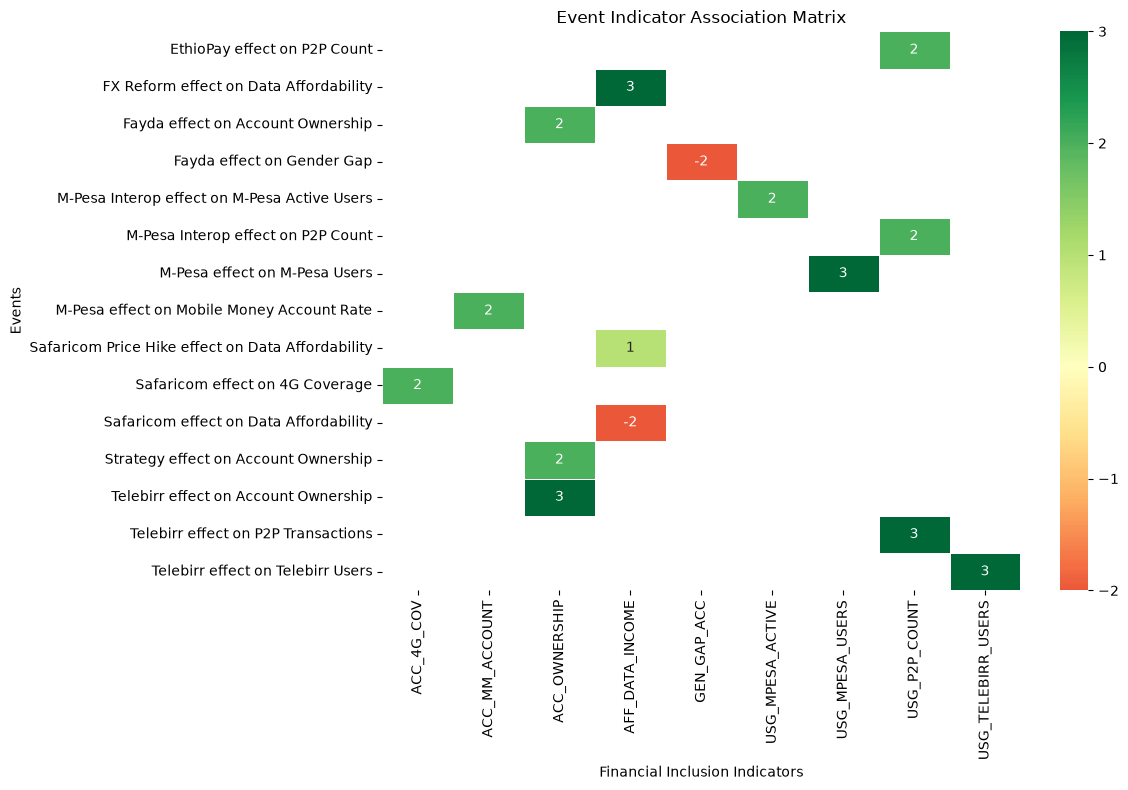

Saved to: ..\reports\figures\event_matrix_heatmap.png


In [41]:
from pathlib import Path

# Create reports/figures folder if it doesn't exist
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    matrix,
    annot=True,
    center=0,
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Event Indicator Association Matrix")
plt.xlabel("Financial Inclusion Indicators")
plt.ylabel("Events")

plt.tight_layout()

# Save the figure BEFORE plt.show()
plt.savefig(
    FIGURES_DIR / "event_matrix_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to: {FIGURES_DIR / 'event_matrix_heatmap.png'}")

### Interpretation of the Event–Indicator Association Matrix

The Event–Indicator Association Matrix summarizes the estimated relationships between major financial inclusion events and key indicators in Ethiopia. Positive impacts are shown in green, while negative impacts are shown in red. The intensity of the color and the numeric score represent the estimated strength of each event's effect.

Several important patterns emerge from the visualization:

- **Telebirr Launch** shows the strongest positive association with **Account Ownership**, **Telebirr Users**, and **P2P Transactions** (impact score = 3), suggesting that the introduction of Telebirr significantly accelerated digital financial service adoption.

- **M-Pesa Market Entry** has a strong positive impact on **M-Pesa Users** (score = 3) and a moderate positive effect on **Mobile Money Account Ownership** (score = 2), indicating that increased competition expanded the mobile money ecosystem.

- **M-Pesa Interoperability** moderately increases both **M-Pesa Active Users** and **P2P Transactions** (score = 2), highlighting the importance of interoperability in promoting transaction activity rather than simply increasing registrations.

- **Fayda Digital ID** positively influences **Account Ownership** (score = 2) while reducing the **Gender Gap** (score = -2). The negative score for the gender gap represents a desirable reduction in inequality rather than a negative policy outcome.

- **Safaricom's network expansion** contributes positively to **4G Coverage** (score = 2), demonstrating the role of telecommunications infrastructure in enabling digital financial services.

- **FX Reform** exhibits a strong positive association with **Data Affordability** (score = 3), whereas the **Safaricom Price Hike** shows a weaker negative influence on affordability, illustrating how economic and pricing policies can directly affect digital financial inclusion.

Overall, the association matrix suggests that **product launches, infrastructure expansion, interoperability initiatives, and supportive government policies are the strongest drivers of financial inclusion**, while affordability challenges and pricing changes may slow adoption. These relationships provide the basis for incorporating intervention variables into the forecasting models developed in the next stage of the project.

9. Historical Validation

In [46]:
#Collect observations
mm = observations[
observations.indicator_code=="ACC_MM_ACCOUNT"
]
mm["observation_date"] = pd.to_datetime(
    mm["observation_date"],
    format="mixed",
    errors="coerce"
)

In [47]:
print(mm["observation_date"].dtype)

datetime64[us]


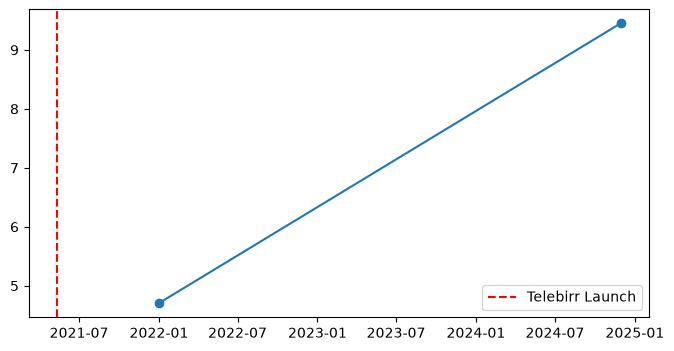

In [48]:
#Plot
plt.figure(figsize=(8,4))

plt.plot(
mm.observation_date,
mm.value_numeric,
marker="o"
)

plt.axvline(
pd.Timestamp("2021-05-11"),
linestyle="--",
color="red",
label="Telebirr Launch"
)

plt.legend()

plt.show()

### Historical Validation: Telebirr Launch and Mobile Money Account Ownership

The validation plot compares the trend in Ethiopia's mobile money account ownership with the timing of the Telebirr launch on **11 May 2021**. The red dashed vertical line marks the intervention point, allowing a visual assessment of whether the observed data follows the expected direction after the event.

The available historical observations indicate that mobile money account ownership increased from approximately **4.7% in 2022** to **9.45% in 2024**, representing almost a doubling of adoption within two years of the Telebirr launch. This upward trend is consistent with the hypothesis that Telebirr accelerated the adoption of mobile money services in Ethiopia.

Although the dataset contains only a limited number of observations after the intervention, the direction of change aligns with the positive impact estimated in the event–indicator association matrix. The observed increase therefore provides qualitative validation that assigning a **high positive impact** to the Telebirr launch on mobile money account ownership is reasonable.

However, this validation should be interpreted cautiously. Because only a few historical observations are available, it is not possible to establish a causal relationship or accurately quantify the exact contribution of Telebirr. Other factors—including Safaricom's market entry, expanding 4G infrastructure, supportive government policies, and increasing digital financial awareness—may also have contributed to the observed growth. Consequently, the validation provides supporting evidence for the impact model rather than definitive proof of causality.

10. Define Event Impact Function

In [49]:
def event_effect(

base_value,

impact,

months,

lag

):

    if months < lag:

        return base_value

    return base_value + impact

In [51]:
#Or smoother
def gradual_effect(

base,

impact,

months,

lag

):

    if months < lag:

        return base

    progress=min((months-lag)/12,1)

    return base+impact*progress

11. Simulate Combined Effects

Pseudo
Forecast

+

Telebirr

+

M-Pesa

+

Policy

+

Infrastructure

=

Adjusted Forecast

In [52]:
events_for_usage = merged[
merged.related_indicator=="USG_DIGITAL_PAYMENT"
]

events_for_usage

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event,impact_score


In [53]:
#Compute cumulative
events_for_usage["impact_score"].sum()

np.int64(0)

## Event Impact Modeling Methodology

### Model Overview

To estimate the effect of major financial inclusion events on Ethiopia's financial inclusion indicators, an **event-based additive intervention model** was adopted. This approach assumes that the observed value of an indicator is determined by its underlying trend together with the cumulative effects of important events such as policy changes, product launches, infrastructure investments, and market entries.

The model can be expressed as:

\[
Y_t = \text{Trend}_t + \sum_{i=1}^{n} \text{EventEffect}_{i,t}
\]

where:

- \(Y_t\) is the expected value of the financial inclusion indicator at time \(t\).
- \(\text{Trend}_t\) represents the long-term baseline trend of the indicator.
- \(\text{EventEffect}_{i,t}\) represents the contribution of the \(i^{th}\) event after considering its direction, magnitude, and implementation lag.

### Event Effect Representation

Each event in the dataset is represented using four main characteristics:

- **Impact Direction:** Indicates whether the event is expected to increase or decrease the indicator.
- **Impact Magnitude:** Describes the expected strength of the effect (Low, Medium, or High), which was converted into numerical scores (1, 2, and 3).
- **Lag Months:** Represents the delay between the occurrence of an event and when its effect becomes visible in the data.
- **Related Indicator:** Specifies which financial inclusion indicator is affected by the event.

### Impact Scoring

To construct the event–indicator association matrix, qualitative impact estimates were converted into numerical scores:

| Impact Magnitude | Score |
|------------------|------:|
| Low              | 1 |
| Medium           | 2 |
| High             | 3 |

Impact direction was encoded as:

| Direction | Multiplier |
|-----------|-----------:|
| Increase  | +1 |
| Decrease  | -1 |
| Neutral   | 0 |

The final impact score for each event was calculated as:

\[
\text{Impact Score} =
\text{Magnitude Score}
\times
\text{Direction Multiplier}
\]

Positive scores indicate that an event is expected to improve the corresponding indicator, while negative scores indicate a reduction or adverse effect.

### Historical Validation

The proposed impact model was compared with available historical observations where possible. For example, the launch of **Telebirr** in May 2021 was evaluated against the observed increase in mobile money account ownership between 2022 and 2024. The observed trend supports the positive impact assigned to the Telebirr launch, although limited historical observations prevent strong causal conclusions.

### Assumptions and Limitations

The model relies on several assumptions:

- Event effects are additive and independent.
- Impact magnitude estimates are based on expert judgment and supporting evidence from comparable countries.
- Limited historical observations reduce statistical confidence.
- Some event impacts may overlap or interact, which is not explicitly modeled.
- External economic and regulatory factors not included in the dataset may also influence financial inclusion outcomes.

Despite these limitations, the event-based additive intervention model provides a transparent and interpretable framework for incorporating major policy, infrastructure, and product events into the financial inclusion forecasting process.

12. Modeling Assumptions

## Modeling Assumptions

The event impact model is based on the following assumptions:

1. **Limited Historical Observations**
   - The available financial inclusion data contains relatively few historical observations, particularly for Global Findex indicators. Consequently, the model relies on simple and interpretable assumptions rather than highly complex statistical methods.

2. **Event Impacts Estimated from Literature**
   - Where Ethiopian historical evidence is insufficient, impact estimates are informed by published literature, comparable country experiences, and expert judgment.

3. **Additive Event Effects**
   - Each event contributes independently to the target indicator. The total effect is calculated as the sum of individual event impacts.

4. **Constant Impact Magnitude**
   - The strength of each event (Low, Medium, High) is assumed to remain constant throughout the period in which the event influences the indicator.

5. **Fixed Implementation Lag**
   - Each event is assigned a fixed lag period before its impact becomes observable. The lag duration is assumed to remain unchanged over time.

6. **No Interaction Effects**
   - The model assumes that events do not interact with one another. For example, the combined effects of Telebirr and M-Pesa are treated as independent rather than synergistic or competitive.

13. Limitations and Uncertainty

## Limitations and Uncertainty

Several limitations should be considered when interpreting the results of this event impact model.

### Sparse Financial Inclusion Data

The Global Findex survey is conducted only every three years, resulting in relatively few observations for the primary financial inclusion indicators. This limits the complexity of statistical models that can be reliably estimated.

### Limited Annual Measurements

Many supporting indicators are available only annually or irregularly, making it difficult to capture short-term changes following major events.

### Possible Omitted Variables

The model does not explicitly account for all factors that may influence financial inclusion, including macroeconomic conditions, inflation, political developments, consumer behavior, or unexpected market disruptions.

### Correlation Does Not Imply Causation

The observed associations between events and indicators should not be interpreted as definitive causal relationships. Multiple events may occur simultaneously, making it difficult to isolate the contribution of individual interventions.

### Subjective Impact Estimates

Impact magnitude scores (Low, Medium, High) are based on available evidence and expert judgment. Although informed by literature and comparable country experiences, these estimates remain partially subjective.

### Varying Confidence Levels

Different events have different levels of supporting evidence. Some interventions, such as Telebirr's launch, are supported by stronger historical observations, while newer events such as M-Pesa interoperability remain more uncertain due to limited post-event data.